<a href="https://colab.research.google.com/github/wathsan11/ML-grape-berries-hyperspectral-/blob/main/GrapeBerriesHyperspectral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 45

##About the GrapeBerries Huperspectural Images Dataset

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning/grapes.csv", sep=";")    # Load the 'grapes.csv' file into a pandas DataFrame, specifying semicolon as the separator
display(df.head())

,Unnamed: 0,Variety,Sugar content (g/l),x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
0,1,SYRAH,144.738,0.143524,0.121990,0.108530,0.098045,0.090435,0.084515,0.078604,...,0.305829,0.312961,0.315948,0.321994,0.328360,0.333273,0.343169,0.351923,0.359960,0.340379
1,2,SYRAH,163.251,0.142029,0.121580,0.107598,0.096139,0.089941,0.083718,0.077647,...,0.314022,0.315759,0.321164,0.325472,0.333227,0.340210,0.350281,0.357942,0.365468,0.342064
2,3,SYRAH,178.398,0.152409,0.128479,0.115143,0.104366,0.097142,0.090982,0.084600,...,0.333914,0.339243,0.340825,0.347567,0.352987,0.361367,0.370589,0.376143,0.387396,0.354477
3,4,SYRAH,193.545,0.150671,0.129675,0.115726,0.105835,0.097539,0.091167,0.085804,...,0.326189,0.329614,0.334720,0.337429,0.342725,0.348176,0.358084,0.362814,0.374406,0.342181
4,5,SYRAH,156.519,0.149406,0.125736,0.113014,0.101396,0.093891,0.087433,0.081891,...,0.317075,0.322848,0.324559,0.331466,0.337053,0.344676,0.354583,0.360175,0.373753,0.342115


In [4]:
df.shape

(274, 207)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Columns: 207 entries, Unnamed: 0 to x.1003.5
dtypes: float64(205), int64(1), object(1)
memory usage: 443.2+ KB


In [6]:
variety = df.Variety
sugarContent = df['Sugar content (g/l)']

In [7]:
print(variety)

0      SYRAH
1      SYRAH
2      SYRAH
3      SYRAH
4      SYRAH
       ...  
269      FER
270      FER
271      FER
272      FER
273      FER
Name: Variety, Length: 274, dtype: object


**Suger Content vs Varity**<br>
There are 3 graph berries types (SYRAH, MAUZAC, FER)

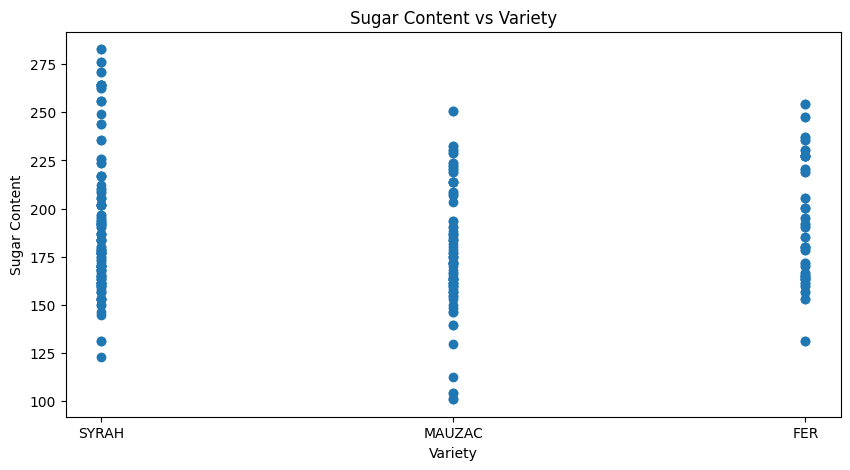

In [9]:
fig1 = plt.figure(figsize=(10,5))
plt.scatter(variety,sugarContent)
plt.ylabel("Sugar Content")
plt.xlabel("Variety")
plt.title("Sugar Content vs Variety")
plt.show()

Quantity of each variety as a pie chart

In [10]:
quantities = df['Variety'].value_counts()
print(quantities)

Variety
SYRAH     126
MAUZAC     85
FER        63
Name: count, dtype: int64


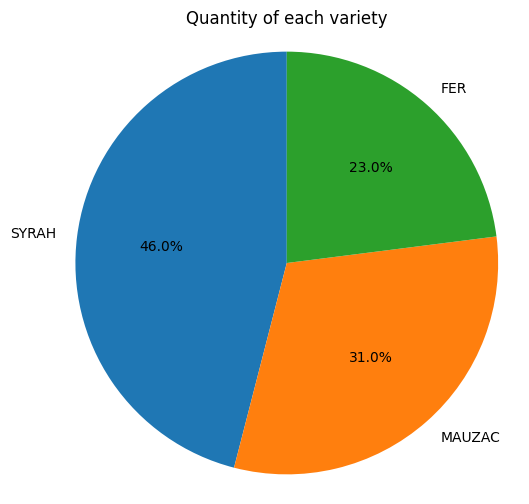

In [15]:
fig2 = plt.figure(figsize=(6,6))
plt.pie(quantities, labels= quantities.index, autopct='%1.1f%%',startangle=90,shadow=False)
plt.axis('equal')
plt.title("Quantity of each variety")
plt.show()

Wavelengths

In [21]:
imgLength_columns_df = df_syrah.filter(regex=r'^x\.')
display(imgLength_columns_df.head())

,x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,x.420.4,x.423.29,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
0,0.143524,0.121990,0.108530,0.098045,0.090435,0.084515,0.078604,0.074226,0.070202,0.066113,...,0.305829,0.312961,0.315948,0.321994,0.328360,0.333273,0.343169,0.351923,0.359960,0.340379
1,0.142029,0.121580,0.107598,0.096139,0.089941,0.083718,0.077647,0.072666,0.068645,0.064228,...,0.314022,0.315759,0.321164,0.325472,0.333227,0.340210,0.350281,0.357942,0.365468,0.342064
2,0.152409,0.128479,0.115143,0.104366,0.097142,0.090982,0.084600,0.080265,0.076254,0.072553,...,0.333914,0.339243,0.340825,0.347567,0.352987,0.361367,0.370589,0.376143,0.387396,0.354477
3,0.150671,0.129675,0.115726,0.105835,0.097539,0.091167,0.085804,0.081407,0.077536,0.073961,...,0.326189,0.329614,0.334720,0.337429,0.342725,0.348176,0.358084,0.362814,0.374406,0.342181
4,0.149406,0.125736,0.113014,0.101396,0.093891,0.087433,0.081891,0.076906,0.072377,0.068974,...,0.317075,0.322848,0.324559,0.331466,0.337053,0.344676,0.354583,0.360175,0.373753,0.342115


In [22]:
imgLength_columns_df.describe()

,x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,x.420.4,x.423.29,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,...,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,0.147631,0.126870,0.113026,0.102870,0.095426,0.088682,0.083012,0.078310,0.074162,0.070540,...,0.345482,0.347977,0.350713,0.355353,0.361343,0.367573,0.376141,0.384249,0.393609,0.359851
std,0.008980,0.008081,0.007940,0.007937,0.007877,0.007839,0.007788,0.007839,0.007859,0.007786,...,0.022341,0.021961,0.022100,0.022189,0.022363,0.022503,0.023047,0.023619,0.023414,0.019624
min,0.125258,0.104410,0.093144,0.083413,0.076369,0.070179,0.065280,0.061012,0.057939,0.054886,...,0.294974,0.297810,0.300904,0.303064,0.310515,0.315913,0.324192,0.331515,0.341979,0.315795
25%,0.142092,0.121998,0.107700,0.097917,0.090065,0.083774,0.078137,0.073505,0.069271,0.065579,...,0.327418,0.331694,0.334653,0.337959,0.344852,0.350216,0.358160,0.365557,0.374941,0.346184
50%,0.146539,0.126719,0.113098,0.102109,0.094964,0.087715,0.082025,0.077056,0.072823,0.069188,...,0.345971,0.350176,0.350802,0.356259,0.361454,0.368210,0.375647,0.385706,0.393957,0.358568
75%,0.152836,0.132181,0.117596,0.108286,0.100594,0.093212,0.087461,0.082694,0.078513,0.074733,...,0.362832,0.365165,0.369057,0.373394,0.379708,0.386808,0.395058,0.403985,0.414180,0.375964
max,0.167832,0.151538,0.138792,0.129504,0.122600,0.116088,0.110159,0.105816,0.101242,0.097500,...,0.392648,0.396783,0.399076,0.406603,0.412161,0.414218,0.423179,0.434619,0.442854,0.402985


**Sugar Content vs imgValue (x.397.32)**

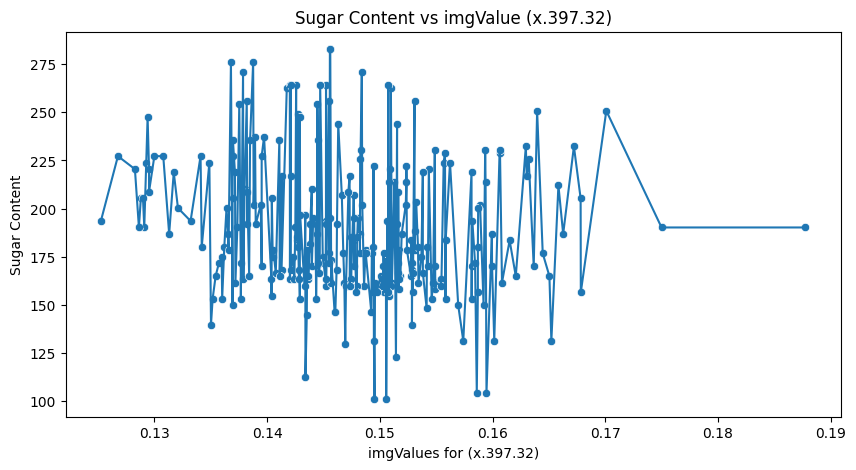

In [16]:
fig3 = plt.figure(figsize=(10,5))
sns.lineplot(x="x.397.32", y="Sugar content (g/l)", data=df)
sns.scatterplot(x="x.397.32", y="Sugar content (g/l)", data=df)
plt.title("Sugar Content vs imgValue (x.397.32)")
plt.xlabel("imgValues for (x.397.32)")
plt.ylabel("Sugar Content")
plt.show()

**Sugar Content vs imgValue (x.397.32) only SYRAH**

In [17]:
df_syrah = df[df['Variety'] == 'SYRAH']
display(df_syrah.head())

,Unnamed: 0,Variety,Sugar content (g/l),x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
0,1,SYRAH,144.738,0.143524,0.121990,0.108530,0.098045,0.090435,0.084515,0.078604,...,0.305829,0.312961,0.315948,0.321994,0.328360,0.333273,0.343169,0.351923,0.359960,0.340379
1,2,SYRAH,163.251,0.142029,0.121580,0.107598,0.096139,0.089941,0.083718,0.077647,...,0.314022,0.315759,0.321164,0.325472,0.333227,0.340210,0.350281,0.357942,0.365468,0.342064
2,3,SYRAH,178.398,0.152409,0.128479,0.115143,0.104366,0.097142,0.090982,0.084600,...,0.333914,0.339243,0.340825,0.347567,0.352987,0.361367,0.370589,0.376143,0.387396,0.354477
3,4,SYRAH,193.545,0.150671,0.129675,0.115726,0.105835,0.097539,0.091167,0.085804,...,0.326189,0.329614,0.334720,0.337429,0.342725,0.348176,0.358084,0.362814,0.374406,0.342181
4,5,SYRAH,156.519,0.149406,0.125736,0.113014,0.101396,0.093891,0.087433,0.081891,...,0.317075,0.322848,0.324559,0.331466,0.337053,0.344676,0.354583,0.360175,0.373753,0.342115


In [19]:
df_syrah.shape

(126, 207)

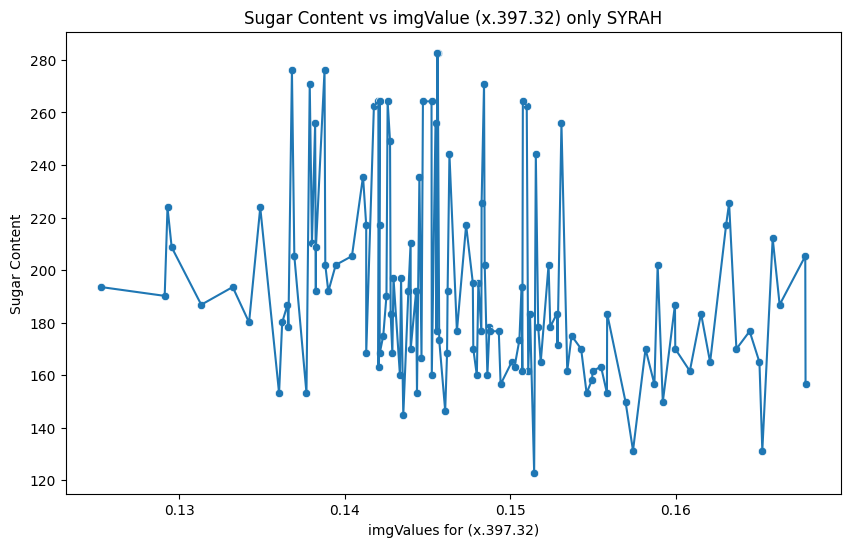

In [26]:
fig4=plt.figure(figsize=(10, 6))
sns.lineplot(x="x.397.32", y="Sugar content (g/l)", data=df_syrah)
sns.scatterplot(x="x.397.32", y="Sugar content (g/l)", data=df_syrah)
plt.title("Sugar Content vs imgValue (x.397.32) only SYRAH")
plt.xlabel("imgValues for (x.397.32)")
plt.ylabel("Sugar Content")
plt.show()

Sugar Content vs imgValue (x.397.32) only MAUZAC

In [23]:
df_MAUZAC = df[df['Variety']=='MAUZAC']
df_MAUZAC.head()

,Unnamed: 0,Variety,Sugar content (g/l),x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
70,71,MAUZAC,203.643,0.153229,0.129270,0.113893,0.103352,0.097116,0.090665,0.085803,...,0.318115,0.321281,0.322143,0.329922,0.336186,0.342872,0.347483,0.358873,0.365303,0.336834
71,72,MAUZAC,185.130,0.147404,0.125345,0.111601,0.102222,0.094935,0.088448,0.083026,...,0.286323,0.288257,0.292519,0.295599,0.301523,0.307624,0.311395,0.322760,0.327541,0.311135
72,73,MAUZAC,169.983,0.154910,0.132844,0.119273,0.109452,0.101267,0.094224,0.088931,...,0.314579,0.313485,0.318355,0.321357,0.328117,0.334484,0.342250,0.348868,0.361682,0.335813
73,74,MAUZAC,148.104,0.154157,0.130793,0.114626,0.103291,0.095695,0.088858,0.082930,...,0.319778,0.323670,0.324927,0.331022,0.333361,0.340341,0.348941,0.360666,0.368063,0.343448
74,75,MAUZAC,188.496,0.153136,0.129781,0.115489,0.103918,0.096806,0.090061,0.084470,...,0.321555,0.324426,0.326343,0.327932,0.333239,0.340568,0.348548,0.353602,0.364910,0.339246


In [25]:
df_MAUZAC.shape

(85, 207)

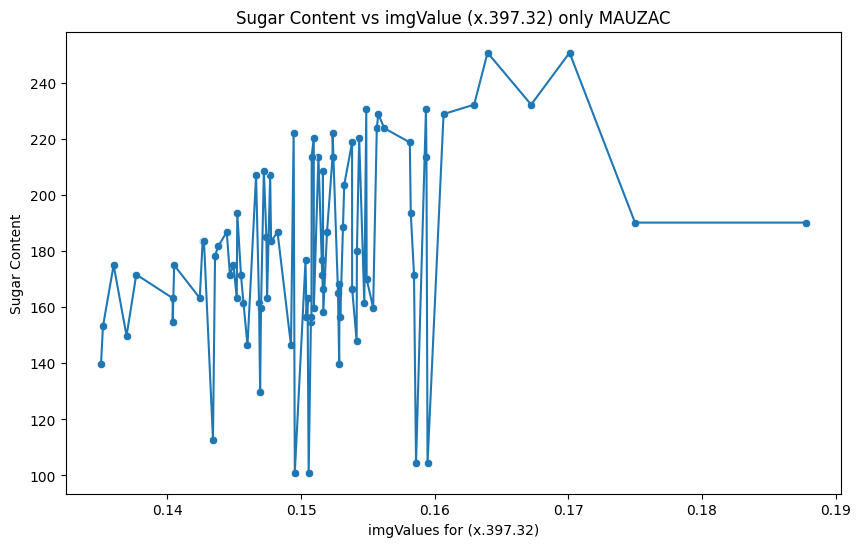

In [27]:
fig5 = plt.figure(figsize=(10, 6))
sns.lineplot(x='x.397.32', y='Sugar content (g/l)', data=df_MAUZAC)
sns.scatterplot(x='x.397.32', y='Sugar content (g/l)', data=df_MAUZAC)
plt.title("Sugar Content vs imgValue (x.397.32) only MAUZAC")
plt.xlabel("imgValues for (x.397.32)")
plt.ylabel("Sugar Content")
plt.show()

Sugar Content vs imgValue (x.397.32) only FER

In [28]:
df_FER = df[df['Variety']=='FER']
df_FER.head()

,Unnamed: 0,Variety,Sugar content (g/l),x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
161,162,FER,131.274,0.149477,0.127806,0.113721,0.102793,0.095053,0.088501,0.081813,...,0.356474,0.357845,0.360900,0.367900,0.376492,0.379142,0.388099,0.404356,0.407416,0.375337
162,163,FER,131.274,0.160154,0.137597,0.122966,0.111622,0.103890,0.097191,0.090906,...,0.382279,0.388751,0.391206,0.391123,0.400883,0.409618,0.417756,0.426123,0.438271,0.406831
163,164,FER,163.251,0.142831,0.122988,0.108052,0.099165,0.092472,0.085898,0.079561,...,0.354108,0.353966,0.356672,0.362960,0.366734,0.371562,0.383511,0.394413,0.404888,0.371900
164,165,FER,163.251,0.151677,0.130103,0.114106,0.104657,0.095697,0.088825,0.082654,...,0.366716,0.372479,0.372571,0.377115,0.385593,0.388876,0.402413,0.411726,0.423335,0.384827
165,166,FER,180.081,0.149373,0.128775,0.114152,0.104844,0.096981,0.089735,0.084408,...,0.345928,0.345948,0.348586,0.355770,0.357846,0.366516,0.379167,0.381852,0.392880,0.368129


In [29]:
df_FER.shape

(63, 207)

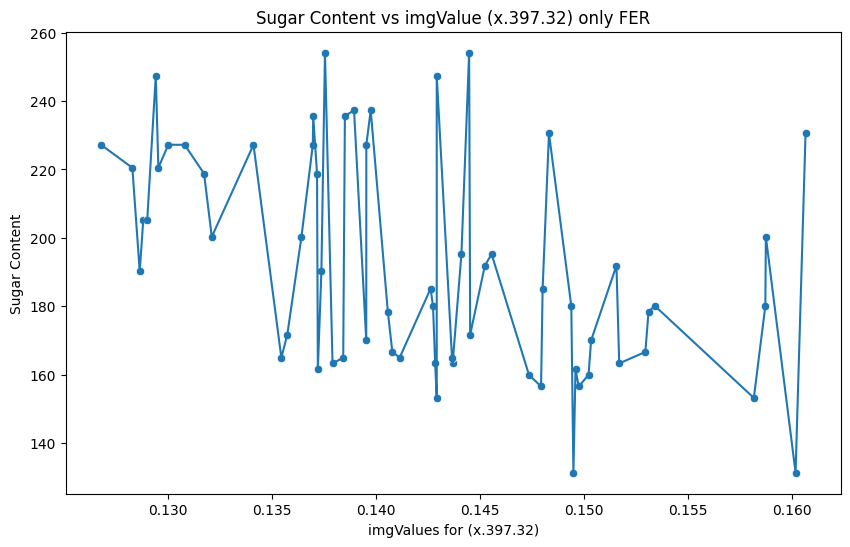

In [31]:
fig6 = plt.figure(figsize=(10, 6))
sns.lineplot(x='x.397.32', y='Sugar content (g/l)', data=df_FER)
sns.scatterplot(x='x.397.32', y='Sugar content (g/l)', data=df_FER)
plt.title("Sugar Content vs imgValue (x.397.32) only FER")
plt.xlabel("imgValues for (x.397.32)")
plt.ylabel("Sugar Content")
plt.show()

/tmp/ipython-input-1582842356.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_FER['Variety'] = 'FER'
/tmp/ipython-input-1582842356.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_MAUZAC['Variety'] = 'MAUZAC'
/tmp/ipython-input-1582842356.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.ht

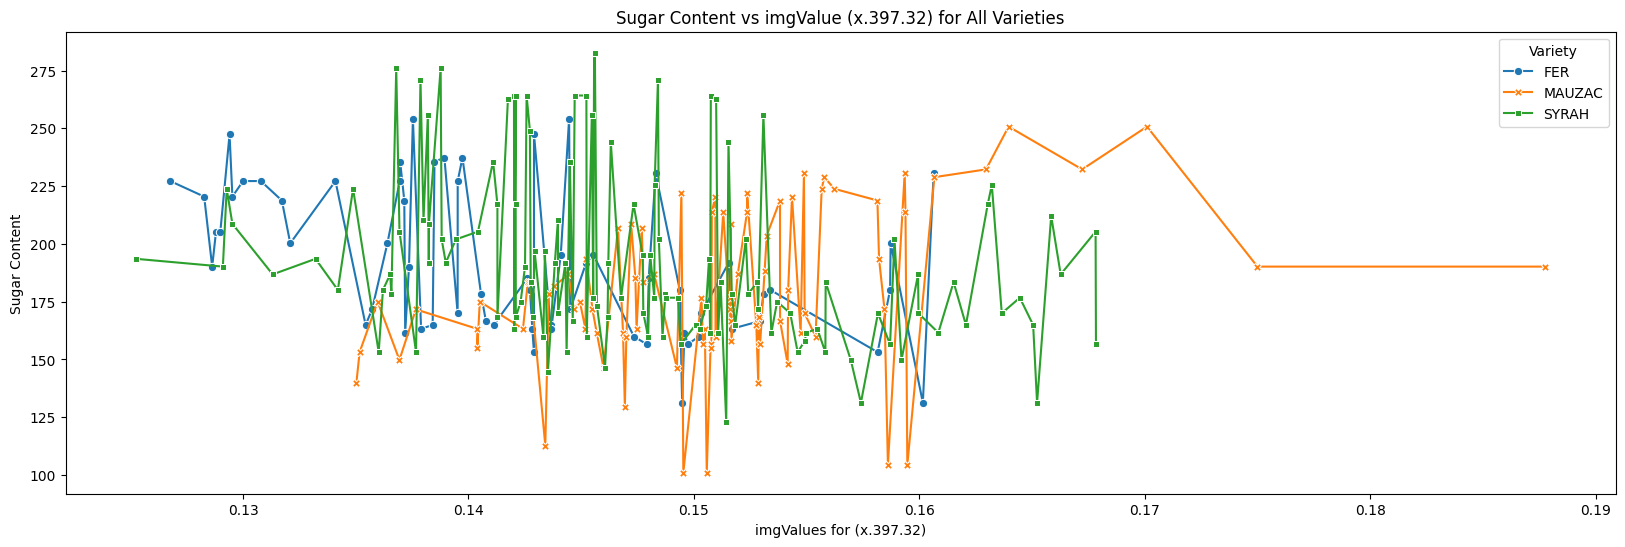

In [34]:
df_FER['Variety'] = 'FER'
df_MAUZAC['Variety'] = 'MAUZAC'
df_syrah['Variety'] = 'SYRAH'

df_all = pd.concat([df_FER, df_MAUZAC, df_syrah])

fig7 = plt.figure(figsize=(20,6))

# Lineplot with hue (color) and style (markers) for each variety
sns.lineplot(
    x='x.397.32',
    y='Sugar content (g/l)',
    hue='Variety',     # color by variety
    style='Variety',   # different marker styles
    markers=True,
    dashes=False,      # solid lines
    data=df_all
)

plt.title("Sugar Content vs imgValue (x.397.32) for All Varieties")
plt.xlabel("imgValues for (x.397.32)")
plt.ylabel("Sugar Content")
plt.legend(title='Variety')
plt.show()

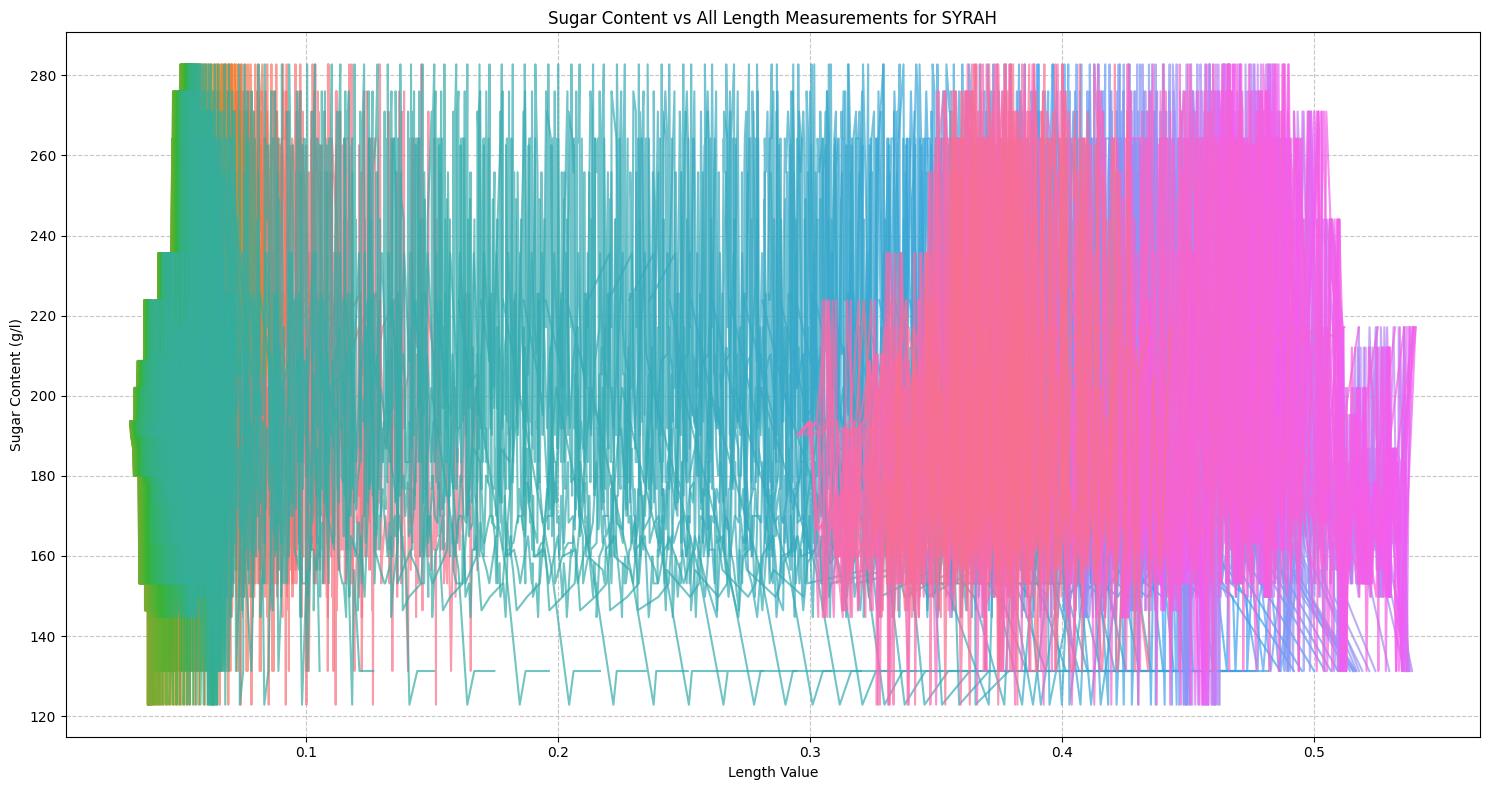

In [ ]:
# Select 'Sugar content (g/l)' and all 'x.' columns from df_syrah
plot_df = df_syrah[list(syrah_length_columns_df.columns) + ['Sugar content (g/l)']]

# Reshape the DataFrame using melt
# This transforms the 'x.' columns into rows, making it suitable for plotting multiple lines
melted_df = plot_df.melt(id_vars=['Sugar content (g/l)'],
                         var_name='Length_Feature',
                         value_name='Length_Value')

plt.figure(figsize=(15, 8))
# Use lineplot to visualize the relationship for each length feature
sns.lineplot(data=melted_df, x='Length_Value', y='Sugar content (g/l)', hue='Length_Feature', alpha=0.7, legend=False)

plt.title("Sugar Content vs All Length Measurements for SYRAH")
plt.xlabel("Length Value")
plt.ylabel("Sugar Content (g/l)")

#Place the legend outside the plot area to prevent obscuring data
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels/legend from being cut off
plt.show()

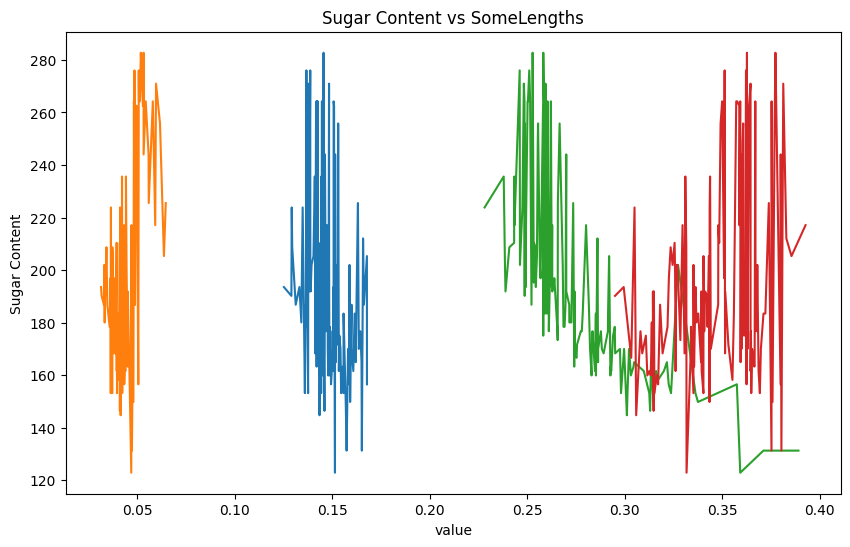

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x="x.397.32", y="Sugar content (g/l)", data=df_syrah)
sns.lineplot(x="x.601.55", y="Sugar content (g/l)", data=df_syrah)
sns.lineplot(x="x.744.53", y="Sugar content (g/l)", data=df_syrah)
sns.lineplot(x="x.975.79", y="Sugar content (g/l)", data=df_syrah)
plt.title("Sugar Content vs SomeLengths")
plt.xlabel("value")
plt.ylabel("Sugar Content")
plt.show()

Data Preprocessing

In [ ]:
x = df.drop(['Sugar content (g/l)', 'Unnamed: 0'], axis=1)
x.head()

,Variety,x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,x.420.4,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
0,SYRAH,0.143524,0.121990,0.108530,0.098045,0.090435,0.084515,0.078604,0.074226,0.070202,...,0.305829,0.312961,0.315948,0.321994,0.328360,0.333273,0.343169,0.351923,0.359960,0.340379
1,SYRAH,0.142029,0.121580,0.107598,0.096139,0.089941,0.083718,0.077647,0.072666,0.068645,...,0.314022,0.315759,0.321164,0.325472,0.333227,0.340210,0.350281,0.357942,0.365468,0.342064
2,SYRAH,0.152409,0.128479,0.115143,0.104366,0.097142,0.090982,0.084600,0.080265,0.076254,...,0.333914,0.339243,0.340825,0.347567,0.352987,0.361367,0.370589,0.376143,0.387396,0.354477
3,SYRAH,0.150671,0.129675,0.115726,0.105835,0.097539,0.091167,0.085804,0.081407,0.077536,...,0.326189,0.329614,0.334720,0.337429,0.342725,0.348176,0.358084,0.362814,0.374406,0.342181
4,SYRAH,0.149406,0.125736,0.113014,0.101396,0.093891,0.087433,0.081891,0.076906,0.072377,...,0.317075,0.322848,0.324559,0.331466,0.337053,0.344676,0.354583,0.360175,0.373753,0.342115


In [ ]:
y = df['Sugar content (g/l)']
y.head()

,Sugar content (g/l)
0,144.738
1,163.251
2,178.398
3,193.545
4,156.519


In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_,y_train,y_=train_test_split(x,y,test_size=0.4,random_state=RANDOM_STATE)
x_cv,x_test,y_cv,y_test=train_test_split(x_,y_,test_size=0.5,random_state=RANDOM_STATE)
del x_,y_

In [ ]:
x_train.head()

,Variety,x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,x.420.4,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
244,FER,0.137363,0.118885,0.106424,0.096758,0.088888,0.083199,0.077651,0.073409,0.069367,...,0.335237,0.334583,0.338519,0.345027,0.349122,0.357528,0.367607,0.374689,0.379399,0.345001
41,SYRAH,0.150717,0.127845,0.113801,0.101908,0.094539,0.086848,0.081153,0.076322,0.071769,...,0.339387,0.343731,0.346231,0.352013,0.358644,0.361020,0.373337,0.380665,0.394069,0.357177
39,SYRAH,0.166267,0.141713,0.127785,0.116219,0.107672,0.100852,0.093157,0.088847,0.083758,...,0.347856,0.350274,0.353164,0.358338,0.367854,0.372276,0.384501,0.392423,0.400444,0.371516
125,SYRAH,0.134881,0.117412,0.104074,0.095686,0.089464,0.082524,0.078181,0.073844,0.069631,...,0.343486,0.343131,0.346293,0.353425,0.356864,0.362661,0.367387,0.376530,0.383219,0.347387
269,FER,0.131722,0.113796,0.103341,0.095964,0.089877,0.085319,0.080727,0.075664,0.072211,...,0.334058,0.334991,0.335628,0.340073,0.343939,0.350302,0.356119,0.365598,0.373545,0.341245


In [ ]:
x_cv.head()

,Variety,x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,x.420.4,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
168,FER,0.151545,0.129878,0.116833,0.107131,0.099860,0.093377,0.087807,0.082670,0.078885,...,0.382482,0.381577,0.387792,0.391210,0.399362,0.401650,0.413682,0.422616,0.431251,0.390199
45,SYRAH,0.145533,0.124821,0.110009,0.100097,0.091272,0.084262,0.078740,0.074664,0.070304,...,0.343349,0.343796,0.348805,0.353027,0.359389,0.368255,0.372962,0.385238,0.393000,0.359378
122,SYRAH,0.129107,0.108298,0.095313,0.085951,0.078123,0.072491,0.067113,0.063307,0.058968,...,0.294974,0.297810,0.300904,0.303064,0.310515,0.315913,0.324192,0.331515,0.341979,0.315795
50,SYRAH,0.155472,0.134759,0.120205,0.110785,0.102057,0.093221,0.087455,0.082668,0.078588,...,0.366429,0.373439,0.375565,0.380864,0.389461,0.390733,0.403438,0.409102,0.417782,0.387287
211,MAUZAC,0.150794,0.127082,0.111800,0.101156,0.094241,0.087494,0.081852,0.077205,0.073500,...,0.308358,0.309403,0.310790,0.317119,0.323491,0.327018,0.336189,0.349748,0.355115,0.331347


In [ ]:
x_test.head()

,Variety,x.397.32,x.400.2,x.403.09,x.405.97,x.408.85,x.411.74,x.414.63,x.417.52,x.420.4,...,x.975.79,x.978.88,x.981.96,x.985.05,x.988.13,x.991.22,x.994.31,x.997.4,x.1000.4,x.1003.5
21,SYRAH,0.164454,0.140551,0.123630,0.110973,0.102326,0.095661,0.088223,0.082962,0.078163,...,0.360700,0.365286,0.368409,0.373458,0.379744,0.388055,0.395132,0.407582,0.416038,0.383451
130,SYRAH,0.141091,0.123679,0.110638,0.101413,0.094087,0.088310,0.082550,0.078217,0.073468,...,0.331015,0.335035,0.336236,0.341423,0.346247,0.349396,0.358390,0.362780,0.376600,0.346457
191,FER,0.149729,0.129002,0.117379,0.108232,0.100629,0.093196,0.087876,0.082385,0.078310,...,0.346337,0.347914,0.352099,0.356373,0.365331,0.368334,0.380782,0.389891,0.399313,0.367088
150,MAUZAC,0.152936,0.133707,0.119018,0.107782,0.098625,0.092366,0.086864,0.081931,0.077745,...,0.345109,0.346561,0.350939,0.356674,0.359985,0.370611,0.378775,0.386267,0.394345,0.365083
109,SYRAH,0.138811,0.118400,0.102731,0.092487,0.086225,0.080630,0.075013,0.070197,0.066543,...,0.326345,0.325943,0.330402,0.337263,0.336853,0.344176,0.352923,0.356932,0.369526,0.335482


In [ ]:
y_train.head()

,Sugar content (g/l)
244,190.179
41,161.568
39,186.813
125,223.839
269,218.790


In [ ]:
y_cv.head()

,Sugar content (g/l)
168,191.862
45,176.715
122,190.179
50,163.251
211,213.741


In [ ]:
y_test.head()

,Sugar content (g/l)
21,176.715
130,235.620
191,156.519
150,156.519
109,201.960


In [ ]:
x_train.isnull().sum()

,0
Variety,0
x.397.32,0
x.400.2,0
x.403.09,0
x.405.97,0
...,...
x.991.22,0
x.994.31,0
x.997.4,0
x.1000.4,0


In [ ]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164 entries, 244 to 131
Columns: 205 entries, Variety to x.1003.5
dtypes: float64(204), object(1)
memory usage: 263.9+ KB


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd # Import pandas

numeric_cols = x_train.select_dtypes(include='float64').columns
categorical_cols = x_train.select_dtypes(include='object').columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols) # Added handle_unknown='ignore' for robustness
])

X_train_processed_array = preprocessor.fit_transform(x_train)
x_cv_processed_array = preprocessor.transform(x_cv)

# Get feature names after transformation
feature_names = preprocessor.get_feature_names_out()

# Convert the processed array to a DataFrame with appropriate column names
X_train_processed = pd.DataFrame(X_train_processed_array, columns=feature_names)
x_cv_processed = pd.DataFrame(x_cv_processed_array, columns=feature_names)

X_train_processed.head()

,num__x.397.32,num__x.400.2,num__x.403.09,num__x.405.97,num__x.408.85,num__x.411.74,num__x.414.63,num__x.417.52,num__x.420.4,num__x.423.29,...,num__x.985.05,num__x.988.13,num__x.991.22,num__x.994.31,num__x.997.4,num__x.1000.4,num__x.1003.5,cat__Variety_FER,cat__Variety_MAUZAC,cat__Variety_SYRAH
0,-1.113371,-0.975061,-0.865129,-0.839887,-0.926629,-0.807859,-0.820911,-0.771195,-0.776418,-0.765456,...,-0.104921,-0.171662,-0.084682,-0.023397,-0.082565,-0.249306,-0.417063,1.0,0.0,0.0
1,0.305488,0.091296,0.059928,-0.179384,-0.183182,-0.325725,-0.350533,-0.378194,-0.450226,-0.470836,...,0.167607,0.193654,0.049262,0.191160,0.135320,0.279776,0.115749,0.0,0.0,1.0
2,1.957662,1.741754,1.813383,1.655852,1.544578,1.524220,1.261534,1.311546,1.178241,1.183094,...,0.414387,0.546977,0.480961,0.609218,0.564055,0.509686,0.743187,0.0,0.0,1.0
3,-1.376996,-1.150365,-1.159828,-0.977312,-0.850849,-0.896968,-0.749693,-0.712404,-0.740632,-0.686402,...,0.222698,0.125354,0.112198,-0.031615,-0.015447,-0.111541,-0.312640,0.0,0.0,1.0
4,-1.712615,-1.580789,-1.251702,-0.941605,-0.796525,-0.527793,-0.407825,-0.466935,-0.390198,-0.293760,...,-0.298204,-0.370488,-0.361814,-0.453552,-0.414040,-0.460460,-0.581423,1.0,0.0,0.0


In [ ]:
x_cv_processed.head()

,num__x.397.32,num__x.400.2,num__x.403.09,num__x.405.97,num__x.408.85,num__x.411.74,num__x.414.63,num__x.417.52,num__x.420.4,num__x.423.29,...,num__x.985.05,num__x.988.13,num__x.991.22,num__x.994.31,num__x.997.4,num__x.1000.4,num__x.1003.5,cat__Variety_FER,cat__Variety_MAUZAC,cat__Variety_SYRAH
0,0.393427,0.333227,0.440146,0.490407,0.516901,0.536730,0.543066,0.478152,0.516360,0.534083,...,1.696872,1.755704,1.607572,1.701929,1.664937,1.620764,1.560728,1.0,0.0,0.0
1,-0.245337,-0.268624,-0.415617,-0.411584,-0.612998,-0.667387,-0.674595,-0.601845,-0.649111,-0.706662,...,0.207188,0.222239,0.326746,0.177138,0.302082,0.241205,0.212066,0.0,0.0,1.0
2,-1.990541,-2.235116,-2.258381,-2.225793,-2.342827,-2.222294,-2.236143,-2.134009,-2.188799,-2.232643,...,-1.742093,-1.652756,-1.680735,-1.649076,-1.656769,-1.598905,-1.695042,0.0,0.0,1.0
3,0.810669,0.914079,0.862992,0.959069,0.805899,0.516102,0.495818,0.477978,0.475952,0.460971,...,1.293232,1.375872,1.188844,1.318319,1.172190,1.135012,1.433299,0.0,0.0,1.0
4,0.313656,0.000470,-0.190994,-0.275782,-0.222373,-0.240373,-0.256747,-0.259097,-0.215119,-0.281832,...,-1.193751,-1.154919,-1.254842,-1.199831,-0.991936,-1.125140,-1.014497,0.0,1.0,0.0


In [ ]:
X_train_processed_array

array([[-1.11337068, -0.97506134, -0.86512931, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.30548796,  0.09129588,  0.05992847, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.95766203,  1.74175449,  1.81338309, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.52322755,  0.32105327,  0.22490262, ...,  0.        ,
         1.        ,  0.        ],
       [-0.42612097, -0.59611374, -0.8623042 , ...,  0.        ,
         0.        ,  1.        ],
       [-0.3552446 , -0.48612768, -0.289106  , ...,  0.        ,
         0.        ,  1.        ]])

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

LinearRegression()

In [ ]:
yhat = linear_model.predict(X_train_processed)

print(f"Training MSE : {mean_squared_error(y_train,yhat)/2}")

Training MSE : 2.0157710838697868e-23


In [ ]:
y_cvhat = linear_model.predict(x_cv_processed)

print(f"CV MSE : {mean_squared_error(y_cv,y_cvhat)/2}")

CV MSE : 1821.9446100376592


In [ ]:
train_MSES =[]
cv_MSES =[]
models = []
polys = []
scalers = []

for degree in range(1:7):
